# Qadence Kickstart: Quantum Machine Learning

This notebook is a comprehensive introduction to machine learning
with a clear path towards Quantum Machine Learning (QML) leaning on the
Psaqal Qadence toolkit.

Qadence is a high-level library built for quantum machine learning.
See https://docs.pasqal.com/qadence/ for more details.

## PyTorch Basics

Here we introduce some PyTorch basics.

* Autograd: gradients for free via `requires_grad=True`. By calling `backward()`, PyTorch computes the gradients for us and stores them in the `.grad` attribute.
* Linspace: create an array of equally spaced values with `torch.linspace`
* Unsqueeze: add a dimension to a tensor, convert an array into a column vector
* RandLike: create random numbers (mean 0, std 1) with the same shape
* Zeros: create a tensor filled with zeros, used for parameters
* Leraning Loop: Forward → Loss → Backward → Update


In [31]:
import torch
torch.manual_seed(20000)

# Autograd
x = torch.tensor(2.0, requires_grad=True)
y = x**3 + 2*x
y.backward()
print(f'x: {x.item()}, y: {y.item()}, x.grad: {x.grad}')

# Linspace, Unsqueeze
X = torch.linspace(-1, 1, 100).unsqueeze(1)
# RandLike, synthesize y = 2x - 1 + noise
y = 2 * X - 1 + 0.1 * torch.randn_like(X)

# parameters we will learn
w = torch.zeros(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.1
for epoch in range(200):
    y_pred = X * w + b                  # forward pass
    loss = ((y_pred - y)**2).mean()     # mean squared error

    loss.backward()                     # fills w.grad, b.grad

    with torch.no_grad():               # don't track the update itself
        w -= lr * w.grad
        b -= lr * b.grad
        w.grad.zero_()                  # gradients accumulate; reset them
        b.grad.zero_()

    if epoch % 50 == 0:
        print(f"epoch {epoch:3d}  loss {loss.item():.4f}  w {w.item():.3f}  b {b.item():.3f}")

print(f"learned: w={w.item():.3f}, b={b.item():.3f}  (true: 2.0, -1.0)")

x: 2.0, y: 12.0, x.grad: 14.0
epoch   0  loss 2.3905  w 0.139  b -0.196
epoch  50  loss 0.0093  w 1.988  b -0.981
epoch 100  loss 0.0081  w 2.042  b -0.981
epoch 150  loss 0.0080  w 2.044  b -0.981
learned: w=2.044, b=-0.981  (true: 2.0, -1.0)


## PyTorch Learning

Now we use built-in PyTorch optimizers and loss functions to learn the same linear model.

In a variational QML program, `model` would be a parameterized quantum circuit instead of `nn.Linear`, but `opt.zero_grad()`, `loss.backward()`, `opt.step()` stay exactly the same. That portability is the whole point of Qadence's PyTorch integration.

* Adam: ADAptive Momentum, dynamically adjusts the step size for each parameter individually. It calculates both the moving average of the gradients (momentum) and the squared gradients to adapt automatically.
* SDG: Stochastic Gradient Descent, uses a fixed (or manually scheduled) step size for all parameters. It is simple but often requires careful tuning to converge.

In [45]:
import torch.nn as nn

torch.manual_seed(20000)
X = torch.linspace(-1, 1, 100).unsqueeze(1)
y = 2 * X - 1 + 0.1 * torch.randn_like(X)

model = nn.Linear(1, 1)                       # w and b live inside
opt = torch.optim.Adam(model.parameters(), lr=0.05)  # ADAM - Dynamically Adjust the search momentum
# opt = torch.optim.SGD(model.parameters(), lr=0.1)    # SDG - Classic descent
loss_fn = nn.MSELoss() # Mean Squared Error
# loss_fn = nn.L1Loss()  # Mean Absolute Error

for epoch in range(300):
    opt.zero_grad()
    loss = loss_fn(model(X), y)
    loss.backward()
    opt.step()

w, b = model.weight.item(), model.bias.item()
print(f"learned: w={w:.3f}, b={b:.3f}  (true: 2.0, -1.0)")

learned: w=2.044, b=-0.981  (true: 2.0, -1.0)


## Extending to 2 Features: Fitting a Plane

Add a second input feature so the model now fits a **plane** in 3D instead of a line in 2D.

- `X1` — the original linear feature (values from -1 to 1)
- `X2` — a sine-wave feature: `sin(π · X1)`
- Target: `y = 2·X1 − 1.5·X2 + 0.3 + noise`

`nn.Linear(2, 1)` gives a weight matrix of shape `(1, 2)` — one output, two inputs.
The learned plane is `ŷ = X @ wᵀ + b`, a flat surface over the `(X1, X2)` feature space.
Because `X2` is derived from `X1`, the data traces a **curve** through that space — the 3D
plot makes this visible.

model.weight shape: (1, 2)
model.bias   shape: (1,)
epoch   0  loss 0.3746  w=[ 0.515 -0.483]  b=0.184
epoch 100  loss 0.0096  w=[ 2.014 -1.513]  b=0.315
epoch 200  loss 0.0095  w=[ 2.024 -1.52 ]  b=0.314
epoch 300  loss 0.0095  w=[ 2.024 -1.52 ]  b=0.314
epoch 400  loss 0.0095  w=[ 2.024 -1.52 ]  b=0.314

learned : w=[ 2.024 -1.52 ], b=0.314
true    : w=[ 2.  -1.5], b=0.3


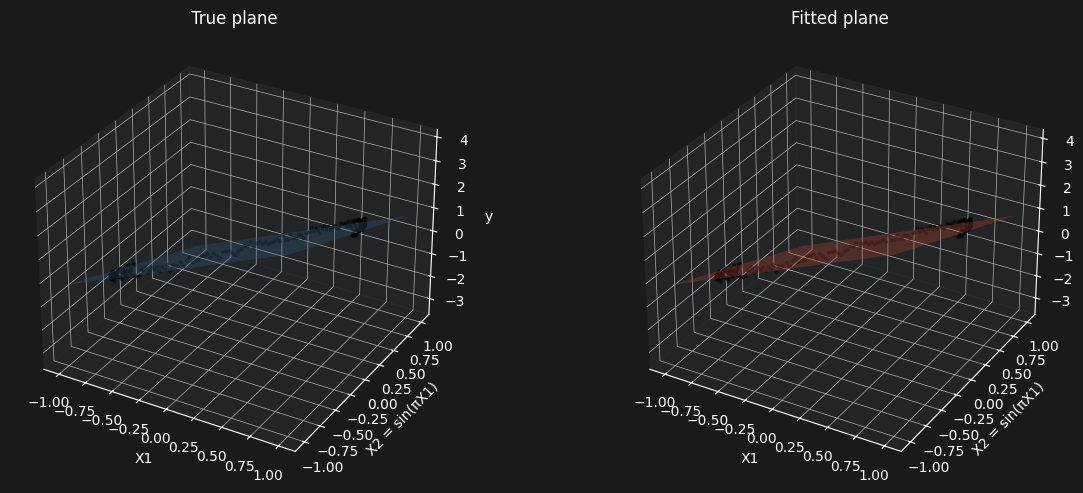

In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(20000)

# --- data: two features ---
N = 200
X1 = torch.linspace(-1, 1, N)
X2 = torch.sin(torch.pi * X1)           # second feature: sine wave of X1

X = torch.stack([X1, X2], dim=1)        # (N, 2)

true_w = torch.tensor([2.0, -1.5])
true_b = 0.3
y = X @ true_w + true_b + 0.1 * torch.randn(N)   # (N,)

# --- model ---
model = nn.Linear(2, 1)
print('model.weight shape:', tuple(model.weight.shape))   # (1, 2)
print('model.bias   shape:', tuple(model.bias.shape))     # (1,)

# --- training ---
opt = torch.optim.Adam(model.parameters(), lr=0.05)
loss_fn = nn.MSELoss()

for epoch in range(500):
    opt.zero_grad()
    loss = loss_fn(model(X).squeeze(), y)
    loss.backward()
    opt.step()
    if epoch % 100 == 0:
        w = model.weight.data.numpy().squeeze().round(3)
        b = model.bias.item()
        print(f'epoch {epoch:3d}  loss {loss.item():.4f}  w={w}  b={b:.3f}')

w_hat = model.weight.data.numpy().squeeze()
b_hat = model.bias.item()
print(f'\nlearned : w={w_hat.round(3)}, b={b_hat:.3f}')
print(f'true    : w={true_w.numpy()}, b={true_b}')

# --- visualize ---
g1 = np.linspace(-1, 1, 40)
g2 = np.linspace(-1, 1, 40)
G1, G2 = np.meshgrid(g1, g2)

Z_true = true_w[0].item() * G1 + true_w[1].item() * G2 + true_b
Z_fit  = w_hat[0] * G1 + w_hat[1] * G2 + b_hat

fig = plt.figure(figsize=(13, 5))

for ax, Z, title, color in [
    (fig.add_subplot(121, projection='3d'), Z_true, 'True plane', 'steelblue'),
    (fig.add_subplot(122, projection='3d'), Z_fit,  'Fitted plane', 'tomato'),
]:
    ax.plot_surface(G1, G2, Z, alpha=0.35, color=color)
    ax.scatter(X1.numpy(), X2.numpy(), y.numpy(), c='k', s=4, alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel('X1'); ax.set_ylabel('X2 = sin(πX1)'); ax.set_zlabel('y')

plt.tight_layout()
plt.show()